## 	Setup, imports, verificación de GPU, semillas

In [7]:
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score, confusion_matrix, classification_report

SEED = 42
tf.keras.utils.set_random_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow:', tf.__version__)
print('GPUs disponibles:', gpus if gpus else 'ninguna (correra en CPU)')

DATA_DIR = Path('data')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
print('DATA_DIR:', DATA_DIR.resolve())
print('RESULTS_DIR:', RESULTS_DIR.resolve())

TensorFlow: 2.21.0
GPUs disponibles: ninguna (correra en CPU)
DATA_DIR: C:\Users\richi\Documents\2026_S2_Local\Data_Science\Data-Science\Lab3\Notebooks\data
RESULTS_DIR: C:\Users\richi\Documents\2026_S2_Local\Data_Science\Data-Science\Lab3\Notebooks\results


>- Utilizamos json poara poder leer y escribir los datos que nos van a ser de utilidad
>- De igual manera importamos keras, libreria que nos ayudara con los entrenamientos de las redes CNN y la fully conected
>- Al pareces TensorFlow no tiene soporte para GPUs en la configuracion actual con windows, el poder de entrenar se realizara usando el poder de la CPU

## Carga de los .npy de A + normalización + sanity check visual

X_train: (12180, 64, 64, 3) uint8 0 255
X_val:   (2610, 64, 64, 3)
X_test:  (2610, 64, 64, 3)
clases: 29 | labels únicos en train: 29


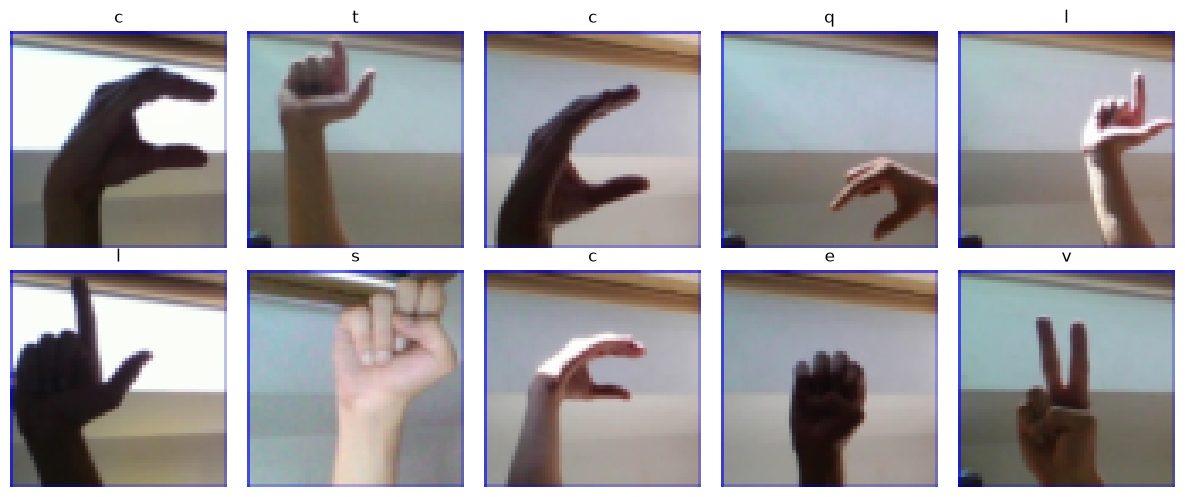

In [8]:
X_train = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
X_val = np.load(DATA_DIR / "X_val.npy")
y_val = np.load(DATA_DIR / "y_val.npy")
X_test = np.load(DATA_DIR / "X_test.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

with open(DATA_DIR / "classes.json") as f:
    class_names = json.load(f)

print("X_train:", X_train.shape, X_train.dtype, X_train.min(), X_train.max
())
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("clases:", len(class_names), "| labels únicos en train:", len(np.unique(y_train)))
assert len(class_names) == len(np.unique(y_train)), "El número de clases no coincide con los labels únicos"

X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_train), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(X_train[idx])
    ax.set_title(class_names[y_train[idx]])
    ax.axis("off")
plt.tight_layout()
plt.show()
plt.show()

> - Cargamos correctamente a memoria los conjuntos X e y para train, validation y test
> - Hicimos un sanity check para confirmaque no se perdio ninguna clase de informacion al momento de traer los datos de memoria
> - Validamos con una semilla random que si se extrayeran bien los datos que hicimos

## Función entrenar_y_evaluar() reutilizable

In [9]:
def entrenar_y_evaluar(model, nombre, aug=False, epochs=30, batch_size=32):
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=2,
    )
    tiempo_entreno_s = time.time() - start

    _, acc_val = model.evaluate(X_val, y_val, verbose=0)
    _, acc_test = model.evaluate(X_test, y_test, verbose=0)

    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    n_params = model.count_params()

    metrics = {
        "modelo": nombre,
        "aug": aug,
        "acc_val": float(acc_val),
        "acc_test": float(acc_test),
        "f1_macro": float(f1_macro),
        "params": int(n_params),
        "tiempo_entreno_s": round(tiempo_entreno_s, 1),
    }
    with open(RESULTS_DIR / f"metrics_{nombre}.json", "w") as f:
        json.dump(metrics, f, indent=2)

    print(f"{nombre}: acc_val={acc_val:.3f} acc_test={acc_test:.3f} f1_macro={f1_macro:.3f} "
          f"params={n_params:,} tiempo={tiempo_entreno_s:.1f}s")

    return {"model": model, "history": history, "metrics": metrics, "y_pred": y_pred}

> Creamos una funcion que sirve para mandar a llamar a los diferentes modelos y que sirva como pipeline para que todos se comporten de la misma manera

## CNN 1 (baseline)

In [10]:
cnn1 = keras.Sequential([
    layers.Conv2D(32, 3, activation="relu", padding="same", input_shape=X_train.shape[1:]),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax"),
], name="CNN1_baseline")

cnn1.summary()

resultado_cnn1 = entrenar_y_evaluar(cnn1, nombre="CNN1_baseline", aug=False)

c:\Users\richi\Documents\2026_S2_Local\Data_Science\Data-Science\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN1_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,145,693 (4.37 MB)

 Trainable params: 1,145,693 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
381/381 - 18s - 48ms/step - accuracy: 0.5332 - loss: 1.6567 - val_accuracy: 0.4502 - val_loss: 2.7126
Epoch 2/30
381/381 - 16s - 43ms/step - accuracy: 0.9365 - loss: 0.2123 - val_accuracy: 0.5249 - val_loss: 3.5642
Epoch 3/30
381/381 - 16s - 43ms/step - accuracy: 0.9830 - loss: 0.0574 - val_accuracy: 0.5529 - val_loss: 4.1103
Epoch 4/30
381/381 - 16s - 43ms/step - accuracy: 0.9886 - loss: 0.0477 - val_accuracy: 0.5625 - val_loss: 4.4471
Epoch 5/30
381/381 - 18s - 46ms/step - accuracy: 0.9878 - loss: 0.0436 - val_accuracy: 0.5659 - val_loss: 4.3579
Epoch 6/30
381/381 - 17s - 44ms/step - accuracy: 0.9935 - loss: 0.0258 - val_accuracy: 0.5835 - val_loss: 4.4686
CNN1_baseline: acc_val=0.450 acc_test=0.424 f1_macro=0.412 params=1,145,693 tiempo=103.4s


> Para 29 clases un accuracy de 0.424 en test esta por encima del azar, igual el f1_macro nos deja ver un poco menos de rendimiento pero de igual manera correcto de 0.412

## 	CNN 2 (profunda)

In [ ]:
cnn2 = keras.Sequential([
    layers.Conv2D(32, 3, activation="relu", padding="same", input_shape=X_train.shape[1:]),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation="softmax"),
], name="CNN2_regularizada")

cnn2.summary()

resultado_cnn2 = entrenar_y_evaluar(cnn2, nombre="CNN2_regularizada", aug=False)

>CNN2 gana en todas las métricas con una décima parte de los parámetros, al estar regularizada, mantuvo val_loss mejorando por más tiempo antes de estancarse, así que entrenó de verdad varias épocas más

## Fully-connected

In [12]:
fc = keras.Sequential([
    layers.Flatten(input_shape=X_train.shape[1:]),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dense(len(class_names), activation="softmax"),
], name="FC")

fc.summary()

resultado_fc = entrenar_y_evaluar(fc, nombre="FC", aug=False)

c:\Users\richi\Documents\2026_S2_Local\Data_Science\Data-Science\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "FC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,430,749 (24.53 MB)

 Trainable params: 6,430,749 (24.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
381/381 - 18s - 46ms/step - accuracy: 0.0471 - loss: 3.5354 - val_accuracy: 0.0682 - val_loss: 3.2798
Epoch 2/30
381/381 - 16s - 42ms/step - accuracy: 0.0626 - loss: 3.2260 - val_accuracy: 0.0640 - val_loss: 3.1936
Epoch 3/30
381/381 - 16s - 43ms/step - accuracy: 0.0770 - loss: 3.1487 - val_accuracy: 0.0716 - val_loss: 3.1712
Epoch 4/30
381/381 - 16s - 42ms/step - accuracy: 0.0833 - loss: 3.1264 - val_accuracy: 0.0885 - val_loss: 3.2731
Epoch 5/30
381/381 - 16s - 42ms/step - accuracy: 0.0911 - loss: 3.0866 - val_accuracy: 0.0755 - val_loss: 3.2022
Epoch 6/30
381/381 - 16s - 42ms/step - accuracy: 0.0998 - loss: 3.0517 - val_accuracy: 0.1176 - val_loss: 3.0298
Epoch 7/30
381/381 - 16s - 42ms/step - accuracy: 0.1006 - loss: 3.0259 - val_accuracy: 0.1291 - val_loss: 2.9776
Epoch 8/30
381/381 - 16s - 42ms/step - accuracy: 0.1097 - loss: 2.9949 - val_accuracy: 0.1057 - val_loss: 3.0561
Epoch 9/30
381/381 - 16s - 42ms/step - accuracy: 0.1269 - loss: 2.9277 - val_accuracy: 0.0981 - 

 >Con 65× más parámetros que CNN2, FC rinde peor que el azar ajustado, 10.6% de accuracy en test, apenas 3× el nivel de adivinar al azar (3.4% con 29 clases), contra CNN2 que llegó a 18× el azar. El f1_macro=0.076 es aún más revelador: tan bajo sugiere que el modelo probablemente colapsó hacia predecir bien solo un puñado de clases (quizás las más fáciles, como nothing o space, que tienen fondos más distintivos) e ignora casi todas las demás

## 	Comparación y selección del mejor

           modelo   aug  params  acc_val  acc_test  f1_macro  tiempo_entreno_s
CNN2_regularizada False   97885 0.678927  0.613410  0.586444             263.5
    CNN1_baseline False 1145693 0.450192  0.423755  0.412394             103.4
               FC False 6430749 0.157854  0.106130  0.075593             290.9

Mejor modelo (sin augmentation): CNN2_regularizada


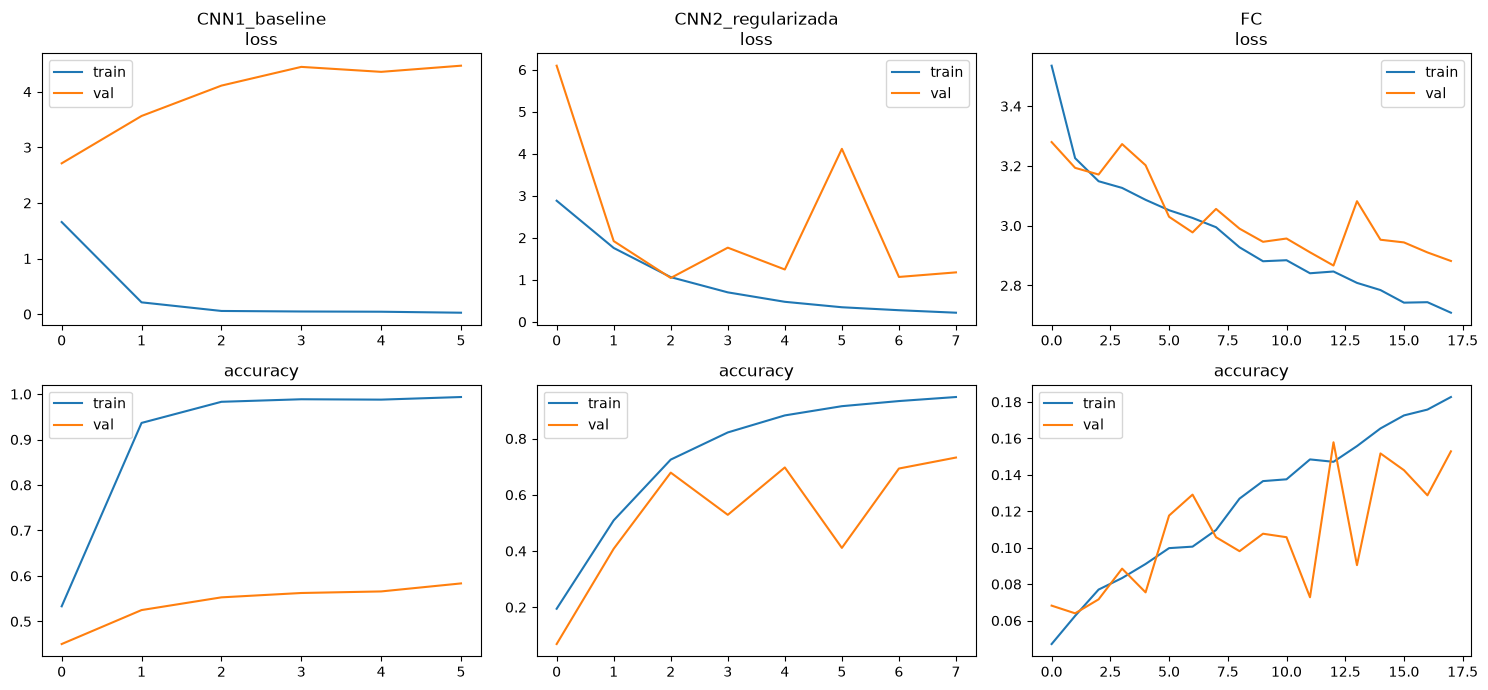

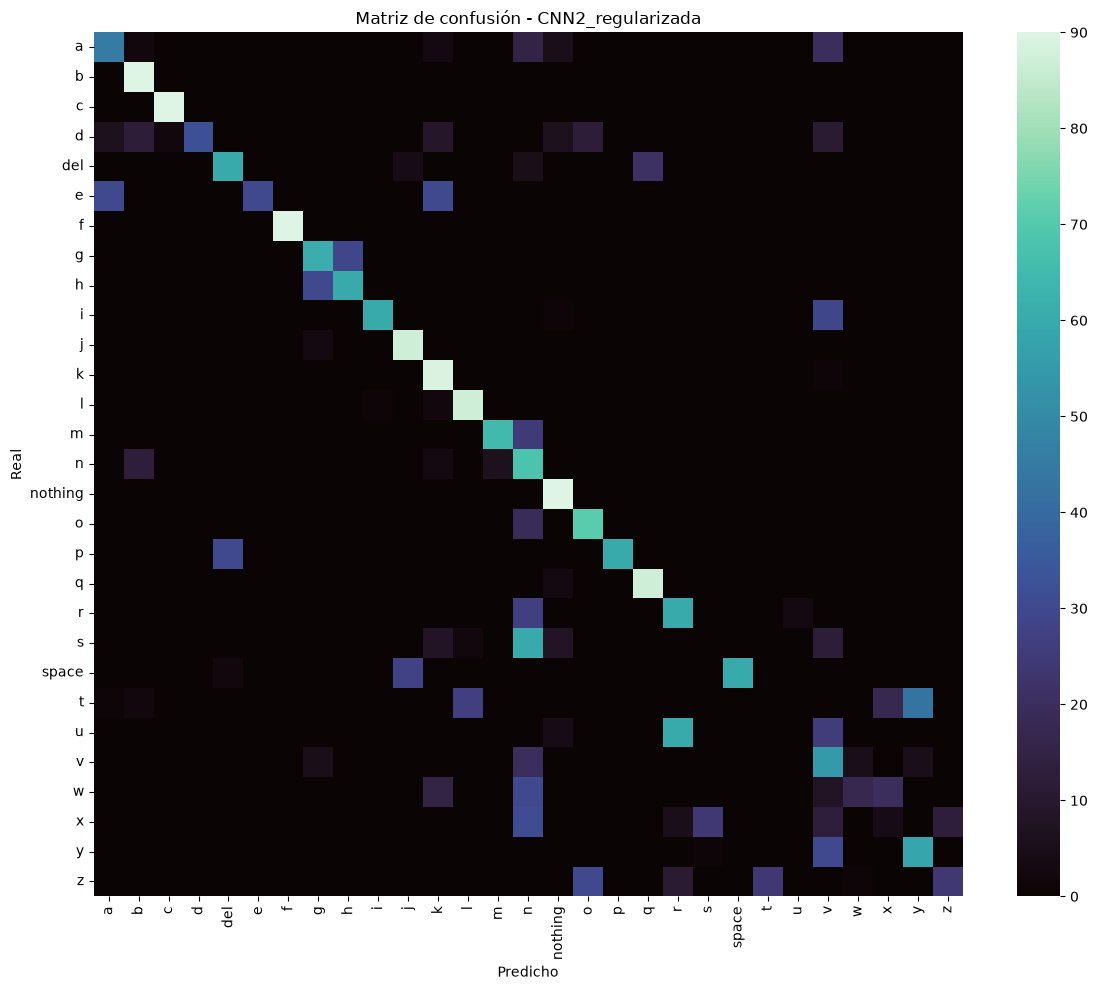


Sub-matriz M/N/S/U/V/R (filas = real, columnas = predicho):
    M   N  S  U   V   R
M  65  25  0  0   0   0
N   6  68  0  0   0   0
S   0  60  0  0  12   0
U   0   0  0  0  26  60
V   0  20  0  0  55   0
R   0  27  0  3   0  60


In [13]:
import pandas as pd
import seaborn as sns

modelos = {
    "CNN1_baseline": resultado_cnn1,
    "CNN2_regularizada": resultado_cnn2,
    "FC": resultado_fc,
}

tabla = pd.DataFrame([r["metrics"] for r in modelos.values()])
tabla = tabla[["modelo", "aug", "params", "acc_val", "acc_test", "f1_macro", "tiempo_entreno_s"]]
tabla = tabla.sort_values("acc_test", ascending=False).reset_index(drop=True)
print(tabla.to_string(index=False))

mejor_nombre = tabla.iloc[0]["modelo"]
mejor = modelos[mejor_nombre]
print(f"\nMejor modelo (sin augmentation): {mejor_nombre}")

# Curvas de loss y accuracy, train vs val, para los 3 modelos
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for col, (nombre, resultado) in enumerate(modelos.items()):
    h = resultado["history"].history
    axes[0, col].plot(h["loss"], label="train")
    axes[0, col].plot(h["val_loss"], label="val")
    axes[0, col].set_title(f"{nombre}\nloss")
    axes[0, col].legend()

    axes[1, col].plot(h["accuracy"], label="train")
    axes[1, col].plot(h["val_accuracy"], label="val")
    axes[1, col].set_title("accuracy")
    axes[1, col].legend()
plt.tight_layout()
plt.show()

# Matriz de confusión del mejor modelo
cm = confusion_matrix(y_test, mejor["y_pred"])
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="mako", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title(f"Matriz de confusión - {mejor_nombre}")
plt.tight_layout()
plt.show()

# Cruce con el EDA: ¿se confunden M/N/S y U/V/R como se predijo?
focus = ["m", "n", "s", "u", "v", "r"]
idx = [class_names.index(c) for c in focus]
sub_cm = pd.DataFrame(cm[np.ix_(idx, idx)], index=[c.upper() for c in focus], columns=[c.upper() for c in focus])
print("\nSub-matriz M/N/S/U/V/R (filas = real, columnas = predicho):")
print(sub_cm.to_string())

> - Podemos ver gracias a la los graficos que el CNN2, con las mismas 3 capas convolucionales que CNN1 pero regularizada (BatchNorm, Dropout, GlobalAveragePooling2D en vez de Flatten+Dense), fue la que mejor desempeño tuvo con 11.7× menos parámetros que CNN1. CNN1 memorizo en train pero al momento de validar no tuvo muy buenos resultados. La FC aprendio pero muyu lento y obtuvo el peor rendimiento de los 3

> - La matriz de confusión confirma que las letras marcadas como problemáticas en el EDA (M/N/S y U/V/R) efectivamente se confunden entre sí. Los casos más extremos son S y U, ambas con recall de 0 el modelo nunca las predice correctamente. S es la más crítica: nunca aparece como predicción en todo el test set (precision indefinida), mientras que sus 90 imágenes reales se reparten entre N (60) y V (12). U tampoco es identificada nunca, cayendo en R (60) y V (26). En ambos casos el error se mantiene dentro del mismo clúster visual que predijo el EDA, no se dispersa hacia letras no relacionadas.

## Pipeline de augmentation + los 3 modelos reentrenados

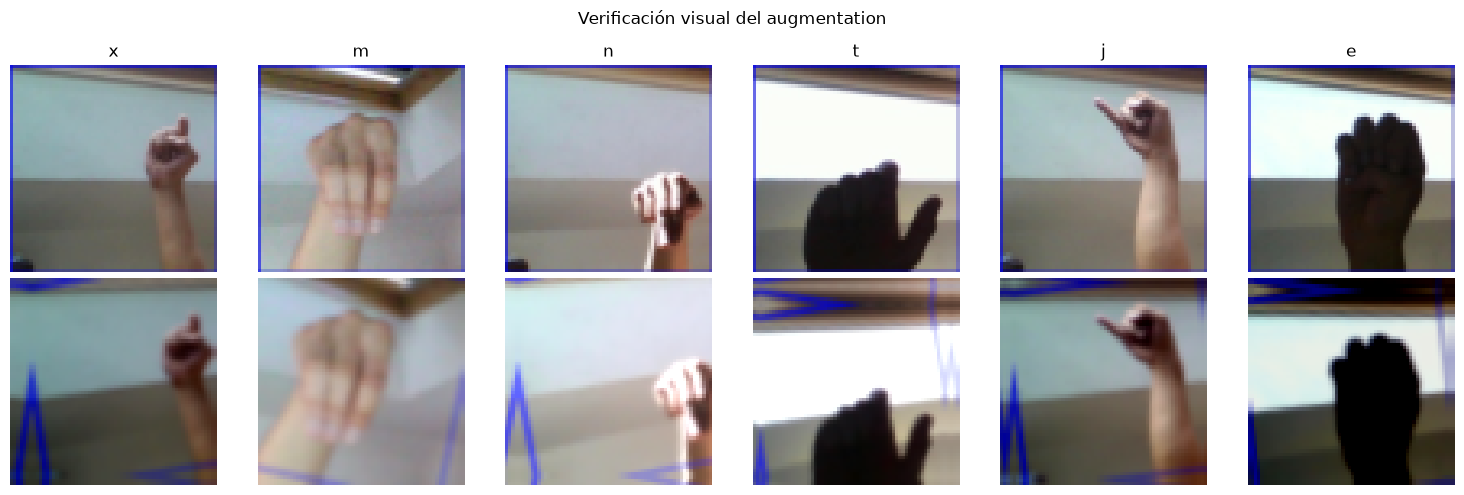

Epoch 1/30
381/381 - 20s - 53ms/step - accuracy: 0.2722 - loss: 2.5261 - val_accuracy: 0.4398 - val_loss: 1.9028
Epoch 2/30
381/381 - 20s - 51ms/step - accuracy: 0.6868 - loss: 1.0120 - val_accuracy: 0.6257 - val_loss: 1.4914
Epoch 3/30
381/381 - 20s - 52ms/step - accuracy: 0.8262 - loss: 0.5422 - val_accuracy: 0.6552 - val_loss: 1.7315
Epoch 4/30
381/381 - 19s - 50ms/step - accuracy: 0.8964 - loss: 0.3388 - val_accuracy: 0.6935 - val_loss: 1.3998
Epoch 5/30
381/381 - 19s - 50ms/step - accuracy: 0.9268 - loss: 0.2324 - val_accuracy: 0.7011 - val_loss: 1.7790
Epoch 6/30
381/381 - 19s - 50ms/step - accuracy: 0.9393 - loss: 0.1907 - val_accuracy: 0.6847 - val_loss: 1.5013
Epoch 7/30
381/381 - 21s - 54ms/step - accuracy: 0.9525 - loss: 0.1555 - val_accuracy: 0.6831 - val_loss: 1.7287
Epoch 8/30
381/381 - 20s - 51ms/step - accuracy: 0.9539 - loss: 0.1377 - val_accuracy: 0.6992 - val_loss: 1.7941
Epoch 9/30
381/381 - 19s - 50ms/step - accuracy: 0.9683 - loss: 0.1003 - val_accuracy: 0.6962 - 

In [14]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.04),                       # ~ ±15°
    layers.RandomTranslation(0.1, 0.1),                # ±10% vertical y horizontal
    layers.RandomZoom(0.1),                            # ±10%
    layers.RandomBrightness(0.2, value_range=(0, 1)),  # X ya está normalizado a [0,1]
    layers.RandomContrast(0.2),
], name="augmentation")

# Grilla: original vs aumentada, para confirmar que las señas siguen siendo legibles
sample_idx2 = rng.choice(len(X_train), size=6, replace=False)
sample_imgs = X_train[sample_idx2]
augmented = data_augmentation(sample_imgs, training=True).numpy()

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    axes[0, i].imshow(sample_imgs[i])
    axes[0, i].set_title(class_names[y_train[sample_idx2[i]]])
    axes[0, i].axis("off")
    axes[1, i].imshow(np.clip(augmented[i], 0, 1))
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Aumentada")
plt.suptitle("Verificación visual del augmentation")
plt.tight_layout()
plt.show()

# --- Los 3 modelos reentrenados, con augmentation como primera capa ---

cnn1_aug = keras.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    data_augmentation,
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax"),
], name="CNN1_aug")
resultado_cnn1_aug = entrenar_y_evaluar(cnn1_aug, nombre="CNN1_aug", aug=True)

cnn2_aug = keras.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    data_augmentation,
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation="softmax"),
], name="CNN2_aug")
resultado_cnn2_aug = entrenar_y_evaluar(cnn2_aug, nombre="CNN2_aug", aug=True)

fc_aug = keras.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    data_augmentation,
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dense(len(class_names), activation="softmax"),
], name="FC_aug")
resultado_fc_aug = entrenar_y_evaluar(fc_aug, nombre="FC_aug", aug=True)

In [ ]:
modelos_aug = {
    "CNN1_aug": resultado_cnn1_aug,
    "CNN2_aug": resultado_cnn2_aug,
    "FC_aug": resultado_fc_aug,
}

tabla_aug = pd.DataFrame([r["metrics"] for r in modelos_aug.values()])
tabla_aug = tabla_aug[["modelo", "aug", "params", "acc_val", "acc_test", "f1_macro", "tiempo_entreno_s"]]
tabla_aug = tabla_aug.sort_values("acc_test", ascending=False).reset_index(drop=True)
print(tabla_aug.to_string(index=False))

mejor_aug_nombre = tabla_aug.iloc[0]["modelo"]
mejor_aug = modelos_aug[mejor_aug_nombre]
print(f"\nMejor modelo (con augmentation): {mejor_aug_nombre}")

# Matriz de confusión del mejor modelo con augmentation
cm_aug = confusion_matrix(y_test, mejor_aug["y_pred"])
plt.figure(figsize=(12, 10))
sns.heatmap(cm_aug, cmap="mako", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title(f"Matriz de confusión - {mejor_aug_nombre}")
plt.tight_layout()
plt.show()

# Misma sub-matriz M/N/S/U/V/R que en la Celda 7, para comparar directamente
# contra el mejor modelo sin augmentation (CNN2_regularizada)
focus = ["m", "n", "s", "u", "v", "r"]
idx = [class_names.index(c) for c in focus]
sub_cm_aug = pd.DataFrame(cm_aug[np.ix_(idx, idx)], index=[c.upper() for c in focus], columns=[c.upper() for c in focus])
print(f"\nSub-matriz M/N/S/U/V/R para {mejor_aug_nombre} (filas = real, columnas = predicho):")
print(sub_cm_aug.to_string())

print("\nPara comparar, la misma sub-matriz de CNN2_regularizada (sin augmentation):")
print(sub_cm.to_string())

## Discusión de augmentation y respuesta al flip horizontal

> A. Lo que pasa con el flip horizontal es que puede convertir una señal a otra completamente diferente. En ASL, las señas se ahcen con una mano dominante, como estan orientados los dedos tambien son parte del significado. El flip puede producir una imagen que se parece a otra real del alfabeto o a una configuracion de mano que no existe en ASL. El modelo aprenderia a que dos formas espejo son la misma clase lo cual no es cierto.

> B. Tienen sentido las que simulan condiciones reales de captura sin alterar l
a forma de la mano: **rotación** ligera (la mano nunca está perfectamente
vertical), **traslación** (la mano no siempre está centrada en el encuadre
), **zoom** (la distancia a la cámara varía) y cambios de **brillo/contras
te** (la iluminación del entorno cambia). Ninguna de estas modifica la con
figuración de los dedos que define la seña

## Exportar mejor_modelo.keras y todos los metrics_*.json

In [16]:
mejor_modelo = mejor["model"]
mejor_modelo.save("mejor_modelo.keras")
print(f"mejor_modelo.keras <- {mejor_nombre} (sin aug, acc_test={mejor['metrics']['acc_test']:.3f})")

mejor_modelo_aug = mejor_aug["model"]
mejor_modelo_aug.save("mejor_modelo_aug.keras")
print(f"mejor_modelo_aug.keras <- {mejor_aug_nombre} (con aug, acc_test={mejor_aug['metrics']['acc_test']:.3f})")

# Tabla final consolidada (los 6 entrenamientos), para el informe
tabla_final = pd.concat([tabla, tabla_aug], ignore_index=True)
tabla_final = tabla_final.sort_values("acc_test", ascending=False).reset_index(drop=True)
tabla_final.to_csv(RESULTS_DIR / "tabla_final.csv", index=False)
print(f"\nresults/tabla_final.csv guardada ({len(tabla_final)} modelos):")
print(tabla_final.to_string(index=False))

print("\nArchivos en results/:")
for f in sorted(RESULTS_DIR.glob("*")):
    print(" -", f.name)

mejor_modelo.keras <- CNN2_regularizada (sin aug, acc_test=0.613)
mejor_modelo_aug.keras <- CNN2_aug (con aug, acc_test=0.849)

results/tabla_final.csv guardada (6 modelos):
           modelo   aug  params  acc_val  acc_test  f1_macro  tiempo_entreno_s
         CNN2_aug  True   97885 0.831801  0.849042  0.848629             664.6
         CNN1_aug  True 1145693 0.693487  0.649425  0.640056             176.6
CNN2_regularizada False   97885 0.678927  0.613410  0.586444             263.5
    CNN1_baseline False 1145693 0.450192  0.423755  0.412394             103.4
           FC_aug  True 6430749 0.127203  0.175479  0.138057             415.5
               FC False 6430749 0.157854  0.106130  0.075593             290.9

Archivos en results/:
 - metrics_CNN1_aug.json
 - metrics_CNN1_baseline.json
 - metrics_CNN2_aug.json
 - metrics_CNN2_regularizada.json
 - metrics_FC.json
 - metrics_FC_aug.json
 - tabla_final.csv
